In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from deepface import DeepFace

In [2]:
img_ngoc1 = cv2.imread('data/raw_name/phan_ngoc/1fcfbd7a-f166-4e35-8a3f-ae65bfebbbe9.jpg')
img_ngoc2 = cv2.imread('data/raw_name/phan_ngoc/b8d0ce6c-a0ea-4bf4-8de2-1ce32c131912.jpg')

In [3]:
print(f"Kích thước ảnh 1: {img_ngoc1.shape}") 
print(f"Kích thước ảnh 2: {img_ngoc2.shape}")

Kích thước ảnh 1: (4032, 3024, 3)
Kích thước ảnh 2: (4097, 2692, 3)


In [4]:
img1_rgb = cv2.cvtColor(img_ngoc1, cv2.COLOR_BGR2RGB)
img2_rgb = cv2.cvtColor(img_ngoc2, cv2.COLOR_BGR2RGB)

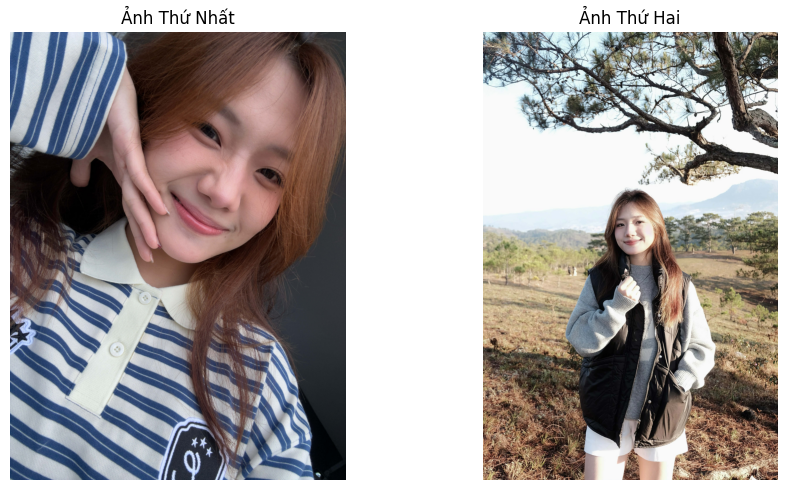

In [6]:
# Trực quan hóa ảnh 
plt.figure(figsize=(10, 5))

    # Ảnh thứ nhất
plt.subplot(1, 2, 1)
plt.imshow(img1_rgb)
plt.title('Ảnh Thứ Nhất')
plt.axis('off') # Ẩn trục tọa độ

# Ảnh thứ hai
plt.subplot(1, 2, 2)
plt.imshow(img2_rgb)
plt.title('Ảnh Thứ Hai')
plt.axis('off')
plt.tight_layout()
plt.show()

# Facenet512

In [7]:
def get_embedding(img):
    result = DeepFace.represent(img_path=img, model_name='Facenet512', enforce_detection=False)
    return np.array(result[0]["embedding"])

In [8]:
embedding_1 = get_embedding(img1_rgb)
embedding_2 = get_embedding(img2_rgb)

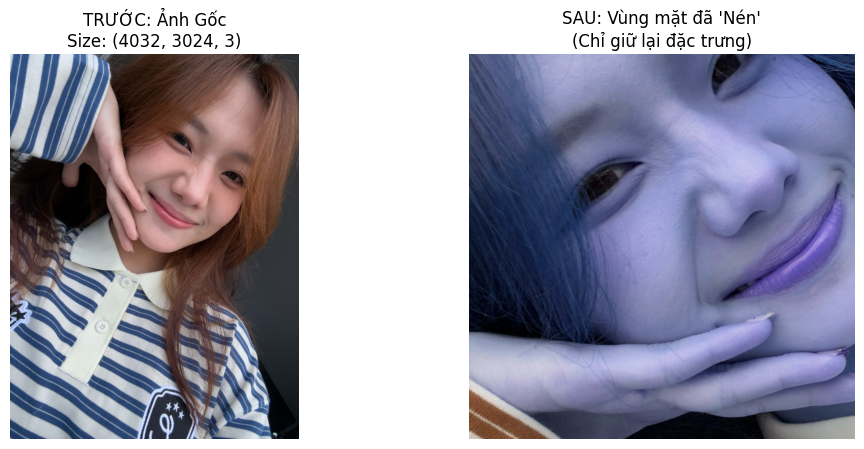

In [9]:
# Trích xuất vùng mặt (AI "nén" sự chú ý vào đây)
face_data1 = DeepFace.extract_faces(img_path=img1_rgb, enforce_detection=False, detector_backend='opencv')[0]['face']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img1_rgb)
plt.title(f"TRƯỚC: Ảnh Gốc\nSize: {img1_rgb.shape}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(face_data1)
plt.title(f"SAU: Vùng mặt đã 'Nén'\n(Chỉ giữ lại đặc trưng)")
plt.axis('off')

plt.show()

In [10]:
# So sánh dung lượng dữ liệu
total_pixels = img1_rgb.size
total_embedding = len(embedding_1)

print(f"--- PHÂN TÍCH MÃ HÓA ---")
print(f"Số lượng đơn vị dữ liệu Ảnh gốc: {total_pixels:,}")
print(f"Số lượng đơn vị dữ liệu sau Mã hóa: {total_embedding}")
print(f"Tỷ lệ tinh gọn: {total_pixels // total_embedding} lần")



--- PHÂN TÍCH MÃ HÓA ---
Số lượng đơn vị dữ liệu Ảnh gốc: 36,578,304
Số lượng đơn vị dữ liệu sau Mã hóa: 512
Tỷ lệ tinh gọn: 71442 lần


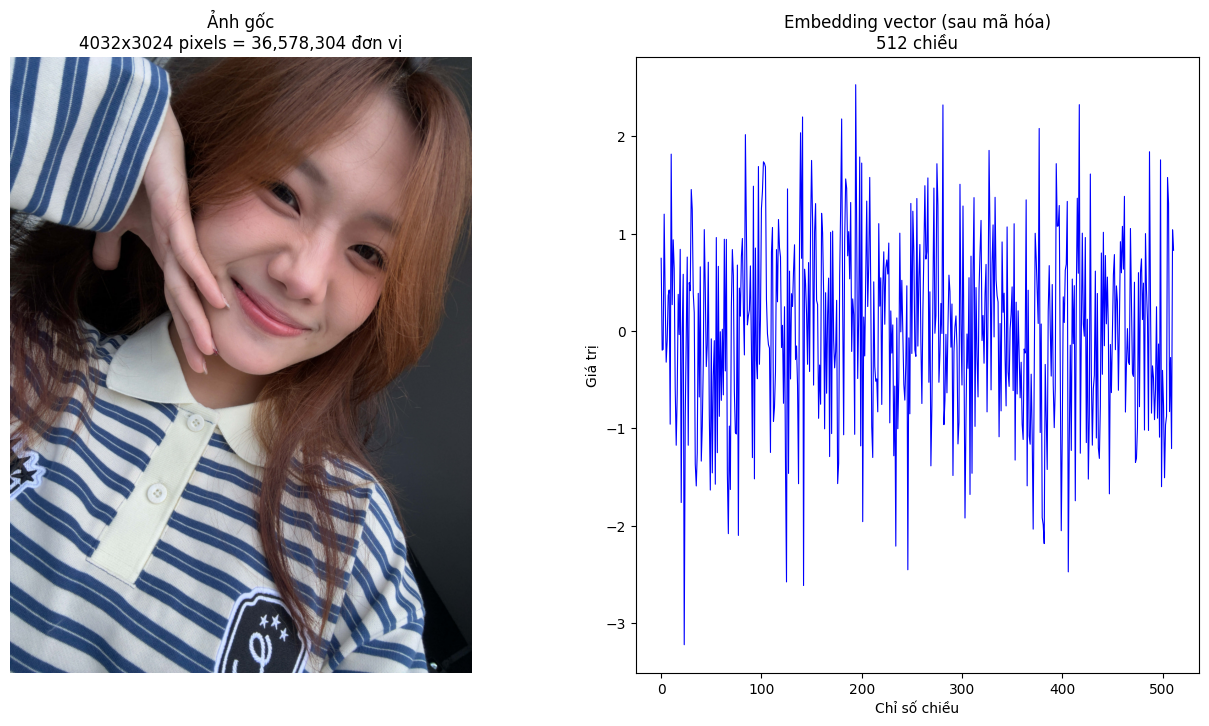

In [11]:
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(img1_rgb)
plt.title(f"Ảnh gốc\n{img1_rgb.shape[0]}x{img1_rgb.shape[1]} pixels = {img1_rgb.size:,} đơn vị")
plt.axis('off')

# 2. Trực quan hóa embedding (sau mã hóa) dưới dạng đường cong
plt.subplot(1, 2, 2)
plt.plot(embedding_1, color='blue', linewidth=0.8)
plt.title(f"Embedding vector (sau mã hóa)\n{len(embedding_1)} chiều")
plt.xlabel("Chỉ số chiều")
plt.ylabel("Giá trị")
plt.show()

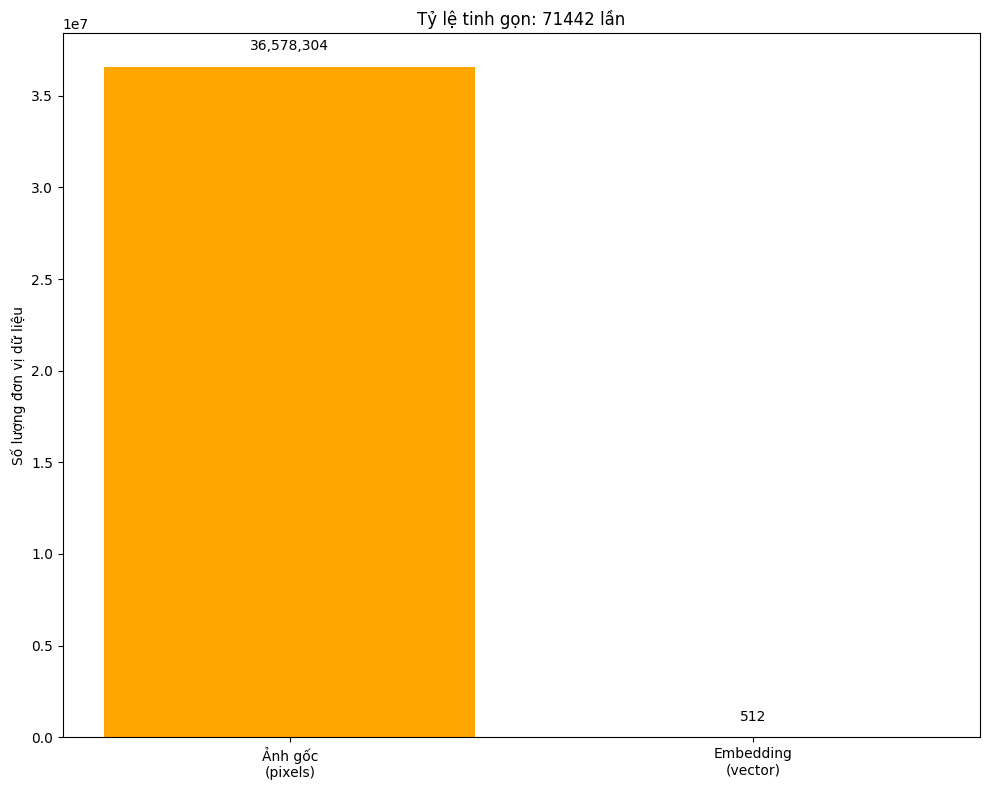

In [12]:
# 3. Biểu đồ so sánh kích thước dữ liệu (tùy chọn)
total_pixels = img1_rgb.size
total_embedding = len(embedding_1)
plt.figure(figsize=(10,8))
categories = ['Ảnh gốc\n(pixels)', 'Embedding\n(vector)']
sizes = [total_pixels, total_embedding]
bars = plt.bar(categories, sizes, color=['orange', 'green'])
plt.ylabel("Số lượng đơn vị dữ liệu")
plt.title(f"Tỷ lệ tinh gọn: {total_pixels // total_embedding} lần")

# Thêm số liệu lên đầu cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02*max(sizes),
             f'{int(height):,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

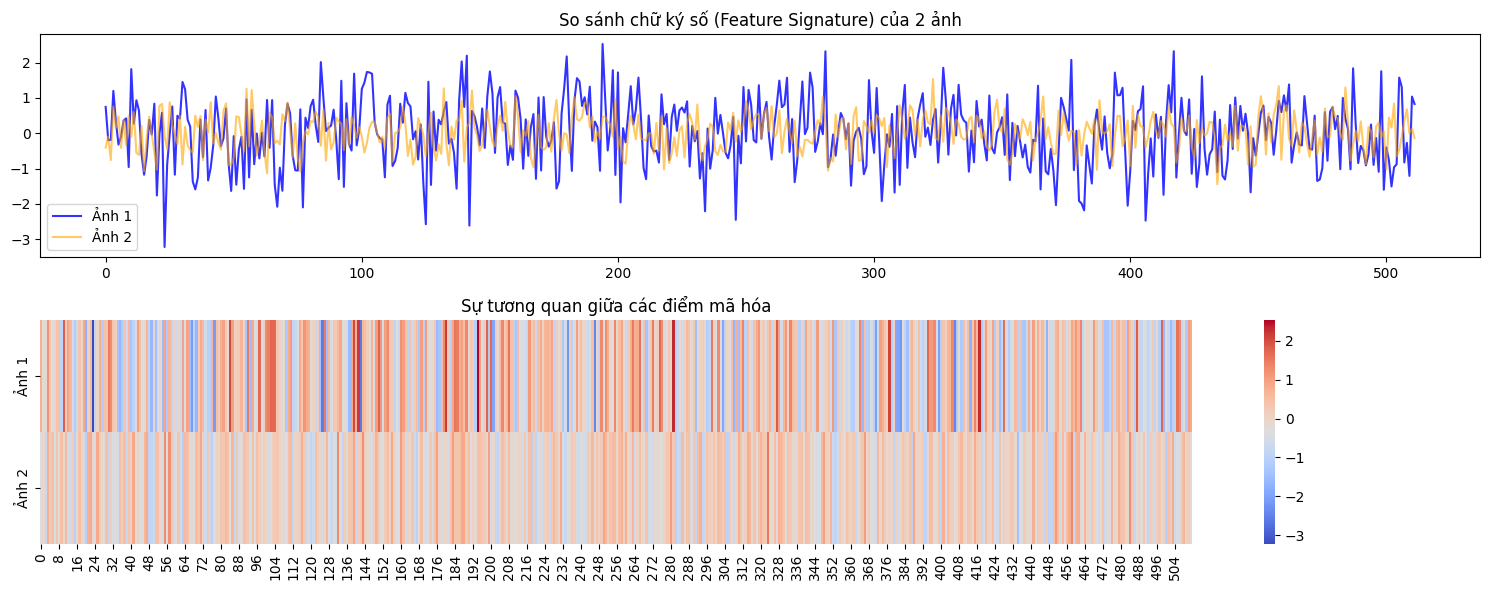

--- KẾT LUẬN ---
Độ tương đồng Cosine: 0.1832 (Gần 1 là rất giống)
Khoảng cách Euclidean: 22.5996 (Càng nhỏ càng giống)


In [13]:
from scipy.spatial import distance

# Tính toán độ tương đồng
cos_sim = 1 - distance.cosine(embedding_1, embedding_2)
euclidean_dist = np.linalg.norm(embedding_1 - embedding_2)

# Vẽ biểu đồ so sánh trực diện
plt.figure(figsize=(15, 6))

plt.subplot(2, 1, 1)
plt.plot(embedding_1, label="Ảnh 1", alpha=0.8, color='blue')
plt.plot(embedding_2, label="Ảnh 2", alpha=0.6, color='orange')
plt.title("So sánh chữ ký số (Feature Signature) của 2 ảnh")
plt.legend()

plt.subplot(2, 1, 2)
sns.heatmap([embedding_1, embedding_2], cmap='coolwarm', yticklabels=['Ảnh 1', 'Ảnh 2'])
plt.title("Sự tương quan giữa các điểm mã hóa")

plt.tight_layout()
plt.show()

print(f"--- KẾT LUẬN ---")
print(f"Độ tương đồng Cosine: {cos_sim:.4f} (Gần 1 là rất giống)")
print(f"Khoảng cách Euclidean: {euclidean_dist:.4f} (Càng nhỏ càng giống)")